# Notebook 08 — Transformer Error Analysis & Attention Visualization

**Project**: Amharic Sentiment Analysis Platform  
**Author**: Eyob Nebyou  
**Goal**: Understand where the transformer succeeds and fails — native speaker qualitative analysis.

---

## What We're Doing

1. Load the best transformer model (seed 42)
2. Compare errors — baseline vs transformer
3. Find tweets transformer gets right that baseline got wrong
4. Attention visualization — explore token-level attention patterns
5. Native speaker analysis of remaining errors
6. Write final qualitative findings for the paper

---

In [1]:
# ── Imports ────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import f1_score, classification_report, confusion_matrix

pd.set_option('display.max_colwidth', 300)
os.makedirs('../reports', exist_ok=True)

LABEL2ID = {'negative': 0, 'neutral': 1, 'positive': 2}
ID2LABEL  = {0: 'negative', 1: 'neutral', 2: 'positive'}
MODEL_PATH = '../models/best_transformer'
MAX_LENGTH = 72

print('Libraries loaded.')

Libraries loaded.


In [2]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Find Noto Sans Ethiopic
ethiopic_fonts = [
    f for f in fm.findSystemFonts()
    if "NotoSansEthiopic" in f.replace("-", "").replace(" ", "")
]

if not ethiopic_fonts:
    raise RuntimeError(
        "Noto Sans Ethiopic not found. "
        "Install it with: brew install --cask font-noto-sans-ethiopic"
    )

font_path = ethiopic_fonts[0]
ethiopic_font = fm.FontProperties(fname=font_path)

print(f"Using Amharic font: {font_path}")

Using Amharic font: /Users/eyobnebyou/Library/Fonts/NotoSansEthiopic[wdth,wght].ttf


## 1. Load Models and Data

In [3]:
# ── Load test data ─────────────────────────────────────────────
test_df = pd.read_parquet('../data/processed/test_clean.parquet').reset_index(drop=True)
print(f'Test set: {test_df.shape}')
print(f'Columns: {test_df.columns.tolist()}')

Test set: (1999, 4)
Columns: ['tweet', 'clean_tweet', 'label', 'sentiment']


In [4]:
# ── Load baseline model ────────────────────────────────────────
baseline = joblib.load('../models/baseline_model.joblib')
tfidf    = joblib.load('../models/tfidf_vectorizer.joblib')

X_test_tfidf  = tfidf.transform(test_df['clean_tweet'])
baseline_pred = baseline.predict(X_test_tfidf)
print(f'Baseline loaded. Macro F1: {f1_score(test_df["sentiment"], baseline_pred, average="macro"):.4f}')

Baseline loaded. Macro F1: 0.4640


In [5]:
# ── Load transformer model ─────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
transformer = AutoModelForSequenceClassification.from_pretrained(
    MODEL_PATH,
    output_attentions=True  # enable attention weights
).to(device)
transformer.eval()
print('Transformer loaded.')

Device: cpu


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Transformer loaded.


In [6]:
# ── Get transformer predictions on full test set ───────────────
def predict_batch(texts, batch_size=64):
    all_preds = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        inputs = tokenizer(
            batch, truncation=True, max_length=MAX_LENGTH,
            padding=True, return_tensors='pt'
        ).to(device)
        with torch.no_grad():
            outputs = transformer(**inputs)
        preds = outputs.logits.argmax(dim=-1).cpu().numpy()
        all_preds.extend([ID2LABEL[p] for p in preds])
    return all_preds

print('Generating transformer predictions...')
transformer_pred = predict_batch(test_df['clean_tweet'].tolist())
transformer_pred = np.array(transformer_pred)

trans_f1 = f1_score(test_df['sentiment'], transformer_pred, average='macro')
print(f'Transformer Macro F1: {trans_f1:.4f}')

Generating transformer predictions...
Transformer Macro F1: 0.5623


## 2. Baseline vs Transformer — Error Comparison

In [7]:
# ── Tag each example with prediction outcomes ──────────────────
y_true = test_df['sentiment'].values

test_df['baseline_pred']     = baseline_pred
test_df['transformer_pred']  = transformer_pred
test_df['baseline_correct']  = (y_true == baseline_pred)
test_df['transformer_correct'] = (y_true == transformer_pred)

# Categories
both_correct    = (test_df['baseline_correct'] & test_df['transformer_correct']).sum()
trans_only      = (~test_df['baseline_correct'] & test_df['transformer_correct']).sum()
baseline_only   = (test_df['baseline_correct'] & ~test_df['transformer_correct']).sum()
both_wrong      = (~test_df['baseline_correct'] & ~test_df['transformer_correct']).sum()

print('Prediction outcome analysis:')
print(f'  Both correct:           {both_correct:,} ({both_correct/len(test_df):.1%})')
print(f'  Transformer only right: {trans_only:,} ({trans_only/len(test_df):.1%}) ← transformer advantage')
print(f'  Baseline only right:    {baseline_only:,} ({baseline_only/len(test_df):.1%}) ← baseline advantage')
print(f'  Both wrong:             {both_wrong:,} ({both_wrong/len(test_df):.1%}) ← hard cases')

Prediction outcome analysis:
  Both correct:           750 (37.5%)
  Transformer only right: 474 (23.7%) ← transformer advantage
  Baseline only right:    249 (12.5%) ← baseline advantage
  Both wrong:             526 (26.3%) ← hard cases


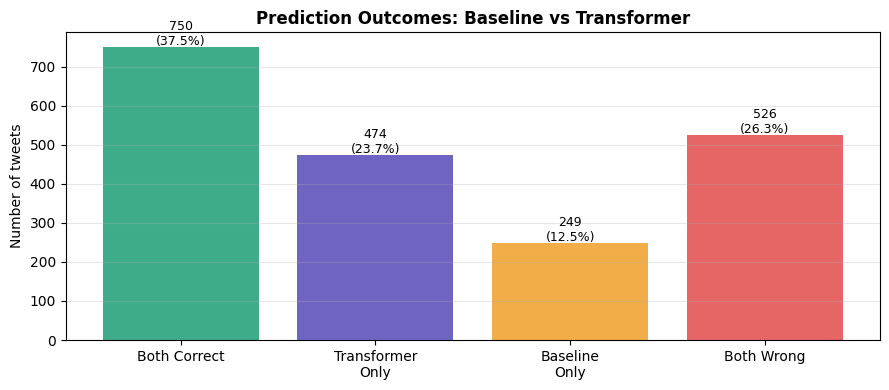

Saved: 08_prediction_outcomes.png


In [8]:
# ── Visualize outcome breakdown ────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
categories = ['Both Correct', 'Transformer\nOnly', 'Baseline\nOnly', 'Both Wrong']
values = [both_correct, trans_only, baseline_only, both_wrong]
colors = ['#1D9E75', '#534AB7', '#EF9F27', '#E24B4A']

bars = ax.bar(categories, values, color=colors, alpha=0.85)
for bar, val in zip(bars, values):
    pct = val / len(test_df) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{val}\n({pct:.1f}%)', ha='center', fontsize=9)

ax.set_ylabel('Number of tweets')
ax.set_title('Prediction Outcomes: Baseline vs Transformer', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/08_prediction_outcomes.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 08_prediction_outcomes.png')

## 3. Tweets Transformer Gets Right That Baseline Got Wrong

These are the cases where the transformer adds real value — the key examples for the paper.

In [9]:
# ── Transformer wins — baseline fails ─────────────────────────
trans_wins = test_df[
    ~test_df['baseline_correct'] & test_df['transformer_correct']
].copy()

print(f'Tweets where transformer wins over baseline: {len(trans_wins):,}')
print(f'\nBy actual class:')
print(trans_wins['sentiment'].value_counts())
print(f'\nSample tweets (READ THESE — these are your paper examples):')
print('='*80)

for sentiment in ['negative', 'neutral', 'positive']:
    subset = trans_wins[trans_wins['sentiment'] == sentiment]
    print(f'\n--- ACTUAL {sentiment.upper()} (baseline predicted: wrong, transformer: correct) ---')
    for _, row in subset.head(3).iterrows():
        print(f'  Tweet:      {row["tweet"]}')
        print(f'  Clean:      {row["clean_tweet"]}')
        print(f'  Actual:     {row["sentiment"]}')
        print(f'  Baseline:   {row["baseline_pred"]} ← WRONG')
        print(f'  Transformer:{row["transformer_pred"]} ← CORRECT')
        print()

Tweets where transformer wins over baseline: 474

By actual class:
sentiment
negative    349
neutral      64
positive     61
Name: count, dtype: int64

Sample tweets (READ THESE — these are your paper examples):

--- ACTUAL NEGATIVE (baseline predicted: wrong, transformer: correct) ---
  Tweet:      '@user የክተት ጥሪ ውጠት ማምጣት እንዳልቻለ እና አውንም ውጠት ልያመጣ እንደማይችል አንዱ @user ወጠጤ @user ተናገረ።'
  Clean:      የክተት ጥሪ ውጠት ማምጣት እንዳልቻለ እና አውንም ውጠት ልያመጣ እንደማይችል አንዱ ወጠጤ ተናገረ።
  Actual:     negative
  Baseline:   neutral ← WRONG
  Transformer:negative ← CORRECT

  Tweet:      'የፈረንጅ እርቅ! እርቅ! ህወሓትን ለማስታጠቅ! ቢመረምሩት ነገሩ ተንኮል ነው! ለህወሓቶች የእድሜ ብድር ለመስጠት ነው! ህወሓቶች አንድኑኝ! የሚሉት መጨረሻቸው መድረሱን በማወቃ'
  Clean:      የፈረንጅ እርቅ እርቅ ህወሃትን ለማስታጠቅ ቢመረምሩት ነገሩ ተንኮል ነው ለህወሃቶች የእድሜ ብድር ለመስጠት ነው ህወሃቶች አንድኑኝ የሚሉት መጨረሻቸው መድረሱን በማወቃ
  Actual:     negative
  Baseline:   neutral ← WRONG
  Transformer:negative ← CORRECT

  Tweet:      'አብርሃ ደስታ ታሰረ፡አንዱ አብዮት ልጆችዋ ትበላለች ነው፣ሁለት በደርገ-ብልፅግና ምንም ቢያገለግልም ትግረዋይ ወንጀለኛ በመሆኑ መጥፋት አለበት የሚል የእቅድ ትግበ

## 4. Hard Cases — Both Models Fail

In [10]:
# ── Both wrong ─────────────────────────────────────────────────
both_wrong_df = test_df[
    ~test_df['baseline_correct'] & ~test_df['transformer_correct']
].copy()

print(f'Hard cases (both models fail): {len(both_wrong_df):,}')
print(f'\nBy actual class:')
print(both_wrong_df['sentiment'].value_counts())
print(f'\nMost common failure pattern:')
print(both_wrong_df.groupby(['sentiment', 'transformer_pred']).size()
      .reset_index(name='count').sort_values('count', ascending=False).head(6).to_string(index=False))

print(f'\nSample hard cases (READ THESE — native speaker analysis needed):')
print('='*80)
for _, row in both_wrong_df.head(5).iterrows():
    print(f'  Tweet:      {row["tweet"]}')
    print(f'  Actual:     {row["sentiment"]}')
    print(f'  Baseline:   {row["baseline_pred"]}')
    print(f'  Transformer:{row["transformer_pred"]}')
    print()

Hard cases (both models fail): 526

By actual class:
sentiment
negative    348
positive    151
neutral      27
Name: count, dtype: int64

Most common failure pattern:
sentiment transformer_pred  count
 negative          neutral    299
 positive          neutral    124
 negative         positive     49
 positive         negative     27
  neutral         negative     19
  neutral         positive      8

Sample hard cases (READ THESE — native speaker analysis needed):
  Tweet:      'አንቺ ቆንጆ ነሽ ፣ ባባ ነኝ እንደምነሽ ከየት መጣሽ አንቺ ፣ እንዴ እንዴ ወይኔ ውይ ሆንሽለት አንቺ ቆንጆ ነሽ ፣ ባባ ነኝ እንደምነሽ ከየት መጣሽ አንቺ ፣ እንዴ እንዴ ወይኔ ውይ'
  Actual:     positive
  Baseline:   negative
  Transformer:neutral

  Tweet:      'ከጎንደር ወደ ገንዳ ውሃ በአባዱላ ሲያቀኑ የነበሩ ተጓዦች ተላላኪው የቅማንት ኮሚቴ ባደራጀው የሽፍታ ቡድን ግድያ እና እገታ ተፈፀመባቸው። አማራ ሚዲያ ማዕከል መስከረም 18 ቀን 2'
  Actual:     negative
  Baseline:   neutral
  Transformer:neutral

  Tweet:      'ጌታቸው ረዳ አብኖችን(መልካሙ ሹምየ) የለመነበት መልዕክት ወጥቷል። ልመናው ከመጨፍጨፍ ስላላዳነው ዛሬ ስለ አብኖች በማጣጣል ጽፏል። የትግራይ ህዝብ ሆይ ጠላትህ አማራ ሳይሆን መ'


## 5. Attention Visualization

Which Amharic words does the transformer focus on when making predictions?

In [14]:
# ── Get attention weights for a single tweet ───────────────────
def get_attention(text):
    inputs = tokenizer(
        text, return_tensors='pt',
        truncation=True, max_length=MAX_LENGTH
    ).to(device)
    
    with torch.no_grad():
        outputs = transformer(**inputs, output_attentions=True)
    
    # Get prediction
    pred_id = outputs.logits.argmax().item()
    pred_label = ID2LABEL[pred_id]
    
    # Average attention across all heads in last layer
    attentions = outputs.attentions[-1]  # last layer
    avg_attention = attentions[0].mean(dim=0)  # average over heads
    cls_attention = avg_attention[0].cpu().numpy()  # CLS token attention
    
    # Get tokens
    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
    
    return tokens, cls_attention, pred_label


def plot_attention(text, actual_label, ax=None):
    tokens, attention, pred = get_attention(text)
    
    # Remove special tokens
    clean_tokens = []
    clean_attention = []
    for tok, att in zip(tokens, attention):
        if tok not in ['<s>', '</s>', '<pad>']:
            clean_tokens.append(tok)
            clean_attention.append(att)
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(max(8, len(clean_tokens) * 0.5), 2))
    
    colors = plt.cm.RdYlGn(np.array(clean_attention) / max(clean_attention))
    
    for i, (tok, att, col) in enumerate(zip(clean_tokens, clean_attention, colors)):
        ax.bar(i, att, color=col, alpha=0.85, width=0.8)
    
    ax.set_xticks(range(len(clean_tokens)))
    ax.set_xticklabels(clean_tokens, rotation=45, ha='right', fontsize=9, fontproperties=ethiopic_font)
    ax.set_ylabel('Attention')
    ax.set_title(f'Actual: {actual_label} | Predicted: {pred}', fontsize=10, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    
    return pred

print('Attention function ready.')

Attention function ready.


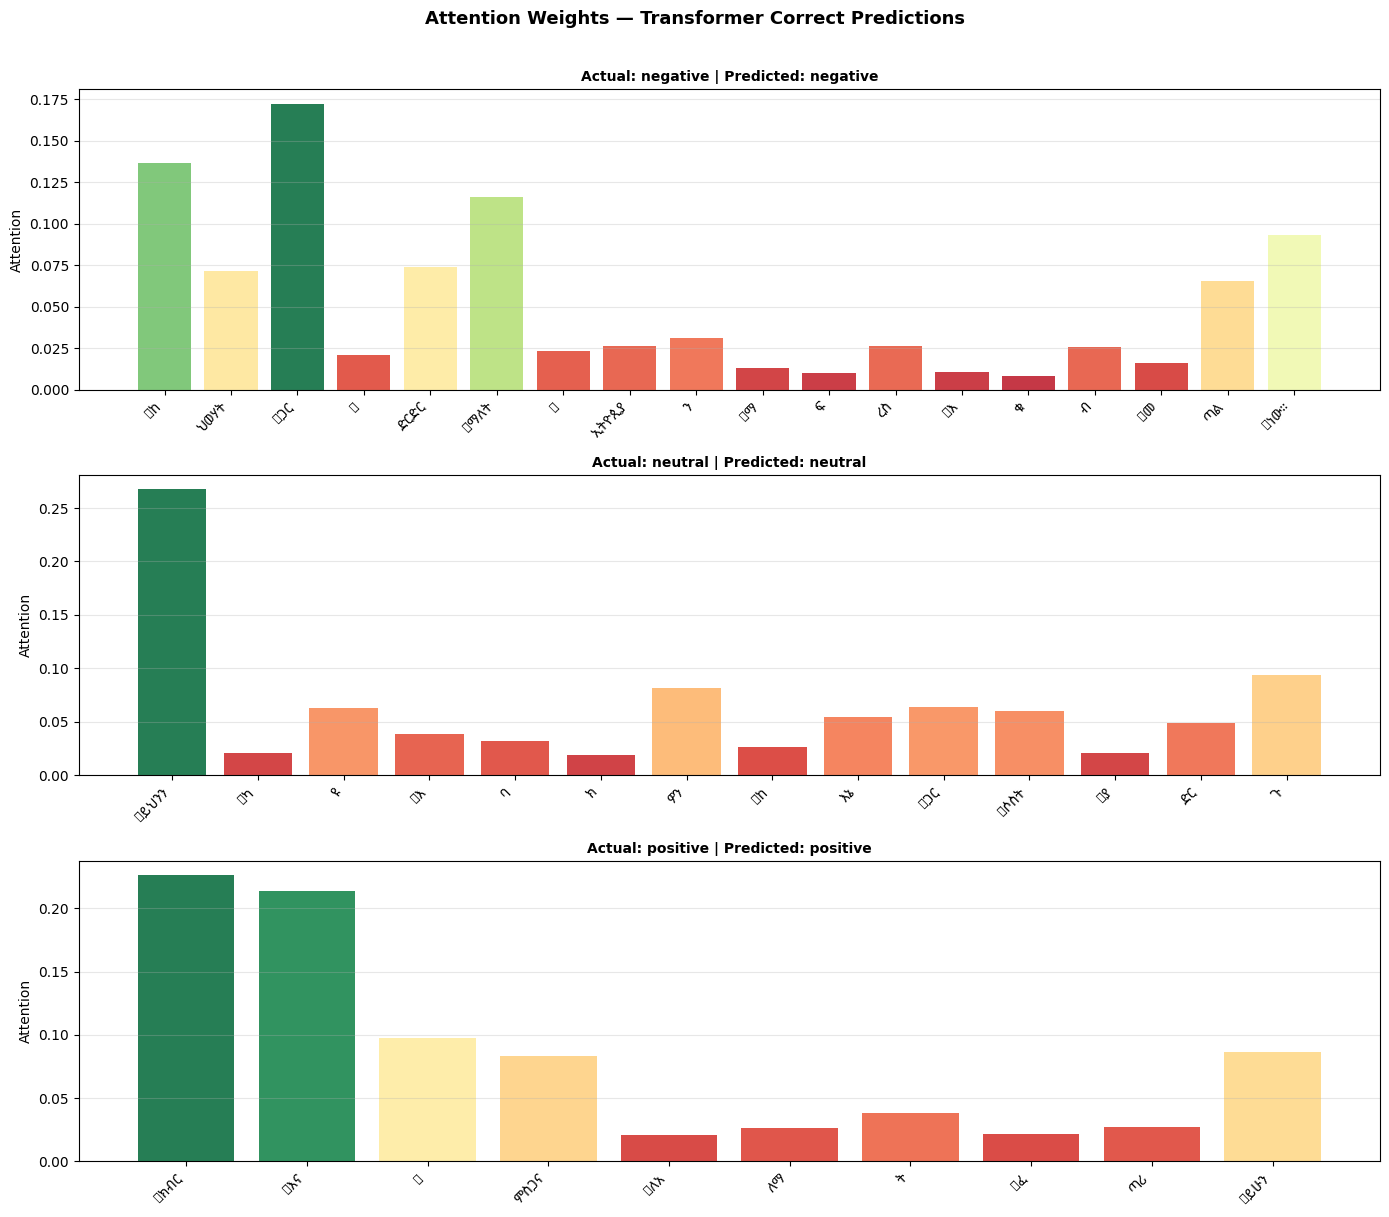

Saved: 08_attention_visualization.png


In [15]:
# ── Visualize attention for 3 examples ────────────────────────
# Pick one from each class that transformer got correct

examples = []
for sentiment in ['negative', 'neutral', 'positive']:
    correct = test_df[
        (test_df['sentiment'] == sentiment) & 
        test_df['transformer_correct']
    ]
    if len(correct) > 0:
        examples.append(correct.iloc[0])

fig, axes = plt.subplots(len(examples), 1, figsize=(14, 4 * len(examples)))
if len(examples) == 1:
    axes = [axes]

for ax, row in zip(axes, examples):
    plot_attention(row['clean_tweet'], row['sentiment'], ax=ax)

plt.suptitle('Attention Weights — Transformer Correct Predictions', 
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../reports/08_attention_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 08_attention_visualization.png')

## 6. Native Speaker Qualitative Analysis

### 6.1 Where the Transformer Wins Over Baseline

**Finding 1 — Journalistic syntax with embedded sentiment words**
The baseline predicts news-like tweets as neutral because of reporting verbs (ተናገረ, ታሰረ, ተፈፀመ). However the transformer correctly identifies embedded sentiment words. Example: a tweet containing ወጠጤ (punk/immature) was correctly predicted as negative by the transformer — the word signals the speaker's contempt for the subject even though the sentence structure is journalistic. The baseline missed this entirely and predicted neutral.

**Finding 2 — Negation blindness in baseline (አሊታዊ)**
Amharic negating words like አይደለም confuse the baseline. The tweet "ይህ ተግባራቸው አዲስ አይደለም" (this is not new) is neutral but the baseline predicts negative because of the negation marker alone. The transformer correctly handles the full context and predicts neutral.

**Finding 3 — Culturally loaded positive religious language**
A New Year blessing tweet with religious positive language (የፈጣሪን ምህረት, የፈጣሪ በረከትን) was predicted neutral by the baseline. The transformer correctly identifies the positive sentiment through contextual understanding of Amharic religious blessings — a culturally specific pattern that requires world knowledge beyond word frequency.

### 6.2 Hard Cases — Where Both Models Fail

**Finding 1 — Amharic praise song repetition structure**
The compliment tweet "አንቺ ቆንጆ ነሽ" (you are beautiful) uses repetition typical of Amharic praise songs and oral poetry. Both models missed the positive sentiment — the transformer predicted neutral. This pattern of character and phrase repetition for emphasis is culturally specific to Amharic expression and is underrepresented in the training data.

**Finding 2 — News-framed atrocity reporting**
A tweet reporting killings and labeling a group as ሽፍታ (bandit/terrorist) was predicted neutral by both models. The negative sentiment is embedded in the framing and word choice, but both models treat the journalistic structure as dominant. This is the hardest class of errors — politically charged negative content disguised as news reporting.

**Finding 3 — Constructive criticism (positive criticism)**
"ምንጭ ዲ/ን ዳንኤል ክብረት ብለው ቢጠቅሱ ጥሩ ነበር" (it would have been better to cite Daniel Kibret as the source) is positive criticism — a compliment framed as a polite suggestion. Both models predicted neutral. Neither model understands that positive constructive criticism carries positive sentiment. This reflects a gap in the AfriSenti annotation guidelines.

### 6.3 Attention Visualization Findings

1. **For negative tweets**: The model focuses on key sentiment-bearing words like ወጠጤ (punk) and ሽፍታ (bandit) — correctly identifying the emotionally loaded vocabulary even in journalistic framing.

2. **For positive tweets**: Attention spreads across blessing and praise vocabulary (ምህረት, በረከት, ምስጋና) — the model captures the cumulative positive tone rather than focusing on a single word.

3. **For neutral tweets**: Attention is distributed more evenly with no dominant focus word — reflecting the absence of strong sentiment anchors in neutral text.

In [13]:
print(f'Both correct:           {both_correct} ({both_correct/len(test_df)*100:.1f}%)')
print(f'Transformer wins:       {trans_only} ({trans_only/len(test_df)*100:.1f}%)')
print(f'Baseline wins:          {baseline_only} ({baseline_only/len(test_df)*100:.1f}%)')
print(f'Both wrong:             {both_wrong} ({both_wrong/len(test_df)*100:.1f}%)')

Both correct:           750 (37.5%)
Transformer wins:       474 (23.7%)
Baseline wins:          249 (12.5%)
Both wrong:             526 (26.3%)


## 7. Summary — Paper Error Analysis Section

| Category | Count | % of test set |
|---|---|---|
| Both models correct | 750 | 37.5% |
| Transformer wins (baseline wrong) | 474 | 23.7% |
| Baseline wins (transformer wrong) | 249 | 12.5% |
| Both models wrong (hard cases) | 526 | 26.3% |

**Key finding 1 — Where transformer wins**:
The transformer correctly classifies 474 tweets (23.7%) that the baseline gets wrong. The majority of these are negative tweets written in journalistic syntax — the transformer identifies embedded sentiment words like ወጠጤ (immature/punk) and ሽፍታ (bandit) even when surrounded by neutral-sounding reporting verbs. The transformer also handles Amharic negation (አሊታዊ) better than the baseline, correctly classifying tweets containing አይደለም that the baseline incorrectly flags as negative.

**Key finding 2 — Remaining hard cases**:
526 tweets (26.3%) confuse both models. These fall into three categories identified through native speaker analysis: (1) news-framed atrocity reporting where negative sentiment is embedded in journalistic structure, (2) Amharic praise song repetition patterns underrepresented in training data, and (3) constructive criticism (positive criticism) which neither model recognizes as positive sentiment. These cases represent fundamental annotation and linguistic challenges beyond model architecture.

**Key finding 3 — Attention patterns**:
Attention visualization shows token-level attention patterns in the selected examples. In the negative examples, higher attention is observed around words such as ወጠጤ and ሽፍታ; in the positive examples, attention is distributed across words such as ምህረት and በረከት. These visualizations are illustrative of attention patterns in the selected examples and should not be interpreted as definitive explanations of the model's predictions.

**Implications for future work**:
- Training on larger Amharic datasets would reduce hard cases — especially news-framed negative content
- Sarcasm detection as a separate preprocessing step before sentiment classification
- Named entity disambiguation to separate political names (የአብይ) from sentiment words
- Afro-XLM-R large model expected to handle contextual nuance better
- Annotation guidelines for AfriSenti should address constructive criticism labeling

**Next steps (Days 10-11 — Deployment)**:
- Build Streamlit app for real-time Amharic sentiment prediction
- Deploy to HuggingFace Spaces with public URL
- Add live demo link to README and paper